# 📊 Phân Tích Biến Động Giá Xăng Dầu Việt Nam (2020–2025)

**Môn học:** Khoa học Dữ liệu  
**Đề tài:** Phân tích biến động giá xăng dầu VN giai đoạn 2020–2025  

---

## ❓ 5 Câu hỏi phân tích

1. Giá xăng RON 95 và E5 biến động như thế nào qua từng năm?
2. Thời điểm nào trong năm giá xăng thường tăng/giảm mạnh nhất?
3. Sự kiện nào tác động lớn nhất đến giá xăng trong giai đoạn này?
4. Mức giá xăng cao nhất và thấp nhất trong 5 năm là bao nhiêu?
5. Xu hướng giá xăng trong 6 tháng tới sẽ như thế nào?


## 1. Import thư viện & Đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Cài đặt font hiển thị tiếng Việt
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Đọc dữ liệu
df = pd.read_csv('xangdau_2020_2025.csv')
df['Ngay'] = pd.to_datetime(df['Ngay'])
df = df.sort_values('Ngay').reset_index(drop=True)

print('✅ Đọc dữ liệu thành công!')
print(f'📅 Từ: {df["Ngay"].min().strftime("%d/%m/%Y")} → {df["Ngay"].max().strftime("%d/%m/%Y")}')
print(f'📝 Số lần điều chỉnh giá: {len(df)} lần')
df.head(10)

✅ Đọc dữ liệu thành công!
📅 Từ: 13/01/2020 → 14/05/2026
📝 Số lần điều chỉnh giá: 62 lần


,Ngay,RON95,E5RON92,DauDiesel,Su_kien
0,2020-01-13,18880,18050,15510,Gia truoc dich COVID
1,2020-03-17,16390,15680,13700,COVID bat dau bung phat
2,2020-04-17,13310,12710,11100,Dau the gioi am lich su
3,2020-05-11,15000,14350,12830,Dau hoi phuc nhe
4,2020-06-26,15000,14350,12530,On dinh
5,2020-08-24,16990,16230,14360,Binh thuong moi
6,2020-10-26,16240,15510,13810,Dich tro lai
7,2020-12-14,17050,16280,14500,Cuoi nam 2020
8,2021-01-25,17600,16820,14970,Dau nam 2021
9,2021-03-22,18580,17760,15440,Vac-xin trien khai


## 2. Tổng quan dữ liệu (EDA)

In [2]:
print('=== THỐNG KÊ MÔ TẢ ===')
print(df[['RON95', 'E5RON92', 'DauDiesel']].describe().round(0))

print('\n=== GIÁ CAO NHẤT ===')
print(f'RON 95: {df["RON95"].max():,} đ/lít (ngày {df.loc[df["RON95"].idxmax(), "Ngay"].strftime("%d/%m/%Y")})')
print(f'E5 RON92: {df["E5RON92"].max():,} đ/lít')
print(f'Dầu Diesel: {df["DauDiesel"].max():,} đ/lít')

print('\n=== GIÁ THẤP NHẤT ===')
print(f'RON 95: {df["RON95"].min():,} đ/lít (ngày {df.loc[df["RON95"].idxmin(), "Ngay"].strftime("%d/%m/%Y")})')
print(f'E5 RON92: {df["E5RON92"].min():,} đ/lít')
print(f'Dầu Diesel: {df["DauDiesel"].min():,} đ/lít')

=== THỐNG KÊ MÔ TẢ ===
         RON95  E5RON92  DauDiesel
count     62.0     62.0       62.0
mean   22526.0  21492.0    21551.0
std     4241.0   4032.0     6483.0
min    13310.0  12710.0    11100.0
25%    20445.0  19492.0    18520.0
50%    21865.0  20865.0    20115.0
75%    24058.0  23076.0    23675.0
max    32870.0  31300.0    43500.0

=== GIÁ CAO NHẤT ===
RON 95: 32,870 đ/lít (ngày 13/06/2022)
E5 RON92: 31,300 đ/lít
Dầu Diesel: 43,500 đ/lít

=== GIÁ THẤP NHẤT ===
RON 95: 13,310 đ/lít (ngày 17/04/2020)
E5 RON92: 12,710 đ/lít
Dầu Diesel: 11,100 đ/lít


## 3. Câu hỏi 1: Biến động giá xăng qua từng năm

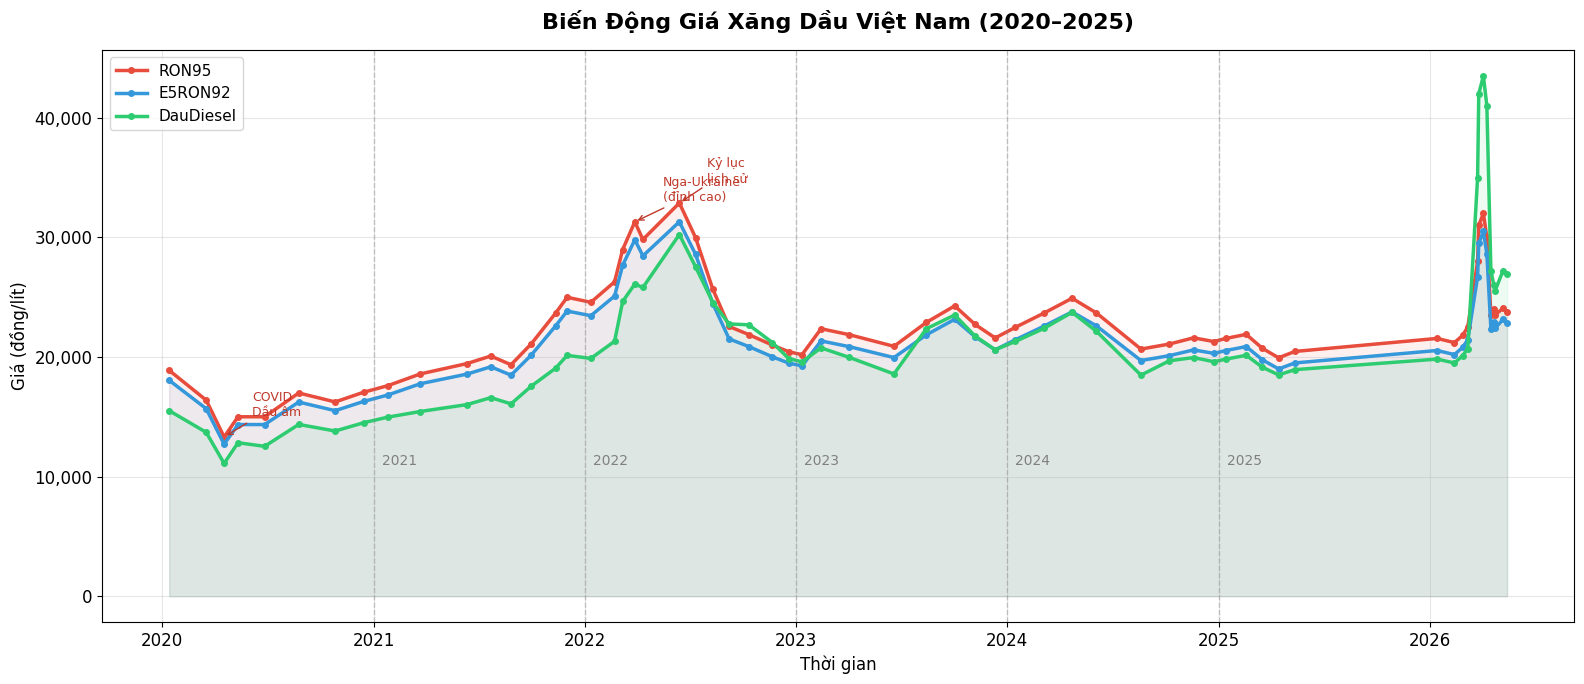

✅ Đã lưu biểu đồ: bieu_do_bien_dong.png


In [3]:
fig, ax = plt.subplots(figsize=(16, 7))

colors = {'RON95': '#e74c3c', 'E5RON92': '#3498db', 'DauDiesel': '#2ecc71'}

for col, color in colors.items():
    ax.plot(df['Ngay'], df[col], color=color, linewidth=2.5, marker='o', 
            markersize=4, label=col)
    ax.fill_between(df['Ngay'], df[col], alpha=0.08, color=color)

# Đánh dấu các sự kiện quan trọng
events = [
    ('2020-04-17', 13310, 'COVID\nDầu âm'),
    ('2022-03-28', 31300, 'Nga-Ukraine\n(đỉnh cao)'),
    ('2022-06-13', 32870, 'Kỷ lục\nlịch sử'),
]
for date, price, label in events:
    ax.annotate(label, xy=(pd.to_datetime(date), price),
                xytext=(20, 15), textcoords='offset points',
                fontsize=9, color='#c0392b',
                arrowprops=dict(arrowstyle='->', color='#c0392b'))

# Phân vùng theo năm
for year in [2021, 2022, 2023, 2024, 2025]:
    ax.axvline(pd.to_datetime(f'{year}-01-01'), color='gray', 
               linestyle='--', alpha=0.4, linewidth=1)
    ax.text(pd.to_datetime(f'{year}-01-15'), 11000, str(year), 
            fontsize=10, color='gray')

ax.set_title('Biến Động Giá Xăng Dầu Việt Nam (2020–2025)', 
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Thời gian', fontsize=12)
ax.set_ylabel('Giá (đồng/lít)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bieu_do_bien_dong.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu biểu đồ: bieu_do_bien_dong.png')

## 4. Câu hỏi 2: Giá trung bình theo năm

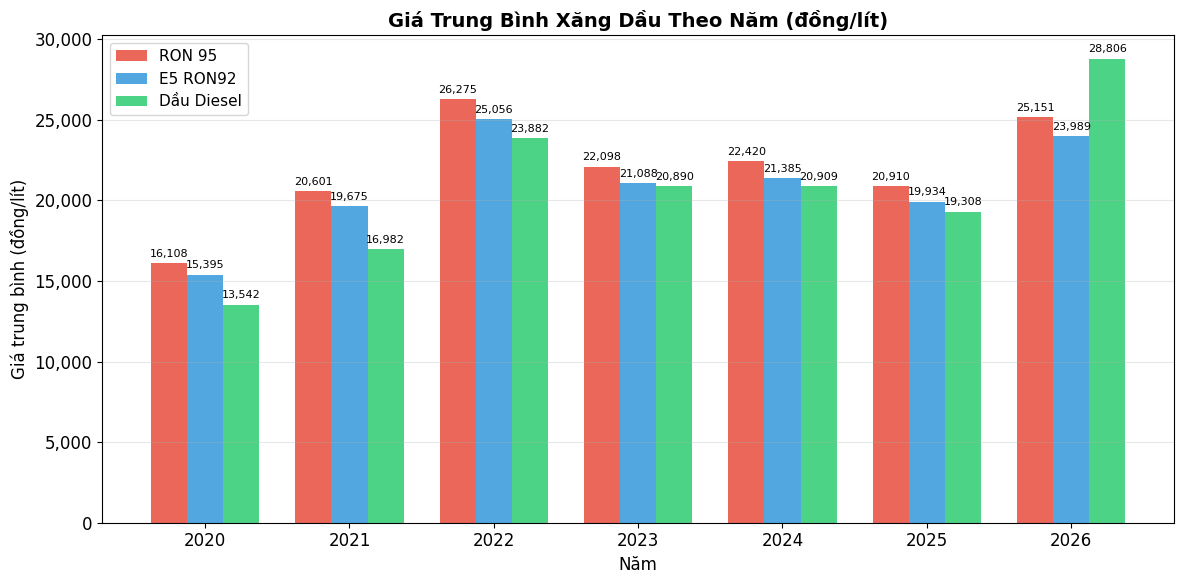


=== BẢNG GIÁ TRUNG BÌNH THEO NĂM ===
        RON95  E5RON92  DauDiesel
Nam                              
2020  16108.0  15395.0    13542.0
2021  20601.0  19675.0    16982.0
2022  26275.0  25056.0    23882.0
2023  22098.0  21088.0    20890.0
2024  22420.0  21385.0    20909.0
2025  20910.0  19934.0    19308.0
2026  25151.0  23989.0    28806.0


In [4]:
df['Nam'] = df['Ngay'].dt.year
gia_nam = df.groupby('Nam')[['RON95', 'E5RON92', 'DauDiesel']].mean().round(0)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(gia_nam))
width = 0.25

bars1 = ax.bar(x - width, gia_nam['RON95'], width, label='RON 95', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x, gia_nam['E5RON92'], width, label='E5 RON92', color='#3498db', alpha=0.85)
bars3 = ax.bar(x + width, gia_nam['DauDiesel'], width, label='Dầu Diesel', color='#2ecc71', alpha=0.85)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:,.0f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

ax.set_title('Giá Trung Bình Xăng Dầu Theo Năm (đồng/lít)', fontsize=14, fontweight='bold')
ax.set_xlabel('Năm', fontsize=12)
ax.set_ylabel('Giá trung bình (đồng/lít)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(gia_nam.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('bieu_do_theo_nam.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== BẢNG GIÁ TRUNG BÌNH THEO NĂM ===')
print(gia_nam.to_string())

## 5. Câu hỏi 3: Sự kiện tác động lớn nhất

=== TOP 5 LẦN TĂNG GIÁ MẠNH NHẤT ===
      Ngay  RON95  ThayDoi_RON95           Su_kien
2026-03-24  28000      24.444444  Dinh cao thang 3
2020-08-24  16990      13.266667   Binh thuong moi
2020-05-11  15000      12.697220  Dau hoi phuc nhe
2021-11-11  23660      12.132701 Gia dau tang manh
2023-02-13  22360      10.747895          Tang nhe

=== TOP 5 LẦN GIẢM GIÁ MẠNH NHẤT ===
      Ngay  RON95  ThayDoi_RON95                       Su_kien
2026-04-16  23540     -21.533333 Giam manh sau chinh sach thue
2020-04-17  13310     -18.791946       Dau the gioi am lich su
2022-08-10  25650     -14.442962                     Giam manh
2020-03-17  16390     -13.188559       COVID bat dau bung phat
2024-08-19  20660     -12.753378                     Giam manh


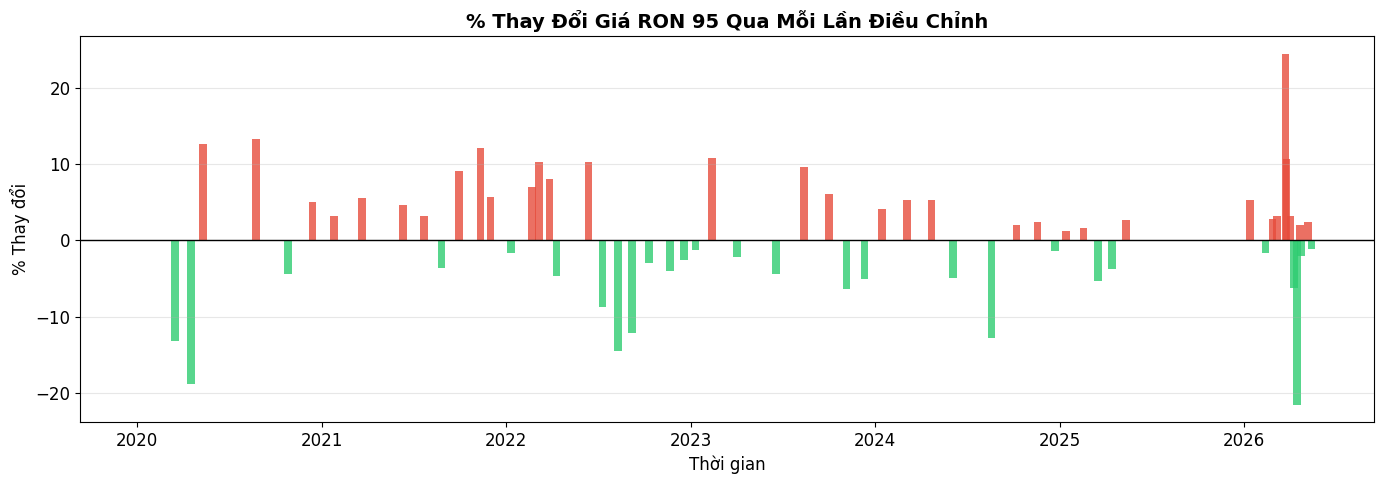

In [5]:
# Tính % thay đổi giữa các lần điều chỉnh
df['ThayDoi_RON95'] = df['RON95'].pct_change() * 100

# Top 5 lần tăng mạnh nhất
top_tang = df.nlargest(5, 'ThayDoi_RON95')[['Ngay', 'RON95', 'ThayDoi_RON95', 'Su_kien']]
print('=== TOP 5 LẦN TĂNG GIÁ MẠNH NHẤT ===')
print(top_tang.to_string(index=False))

# Top 5 lần giảm mạnh nhất
top_giam = df.nsmallest(5, 'ThayDoi_RON95')[['Ngay', 'RON95', 'ThayDoi_RON95', 'Su_kien']]
print('\n=== TOP 5 LẦN GIẢM GIÁ MẠNH NHẤT ===')
print(top_giam.to_string(index=False))

# Vẽ biểu đồ % thay đổi
fig, ax = plt.subplots(figsize=(14, 5))
colors_bar = ['#e74c3c' if x > 0 else '#2ecc71' for x in df['ThayDoi_RON95'].fillna(0)]
ax.bar(df['Ngay'], df['ThayDoi_RON95'].fillna(0), color=colors_bar, alpha=0.8, width=15)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('% Thay Đổi Giá RON 95 Qua Mỗi Lần Điều Chỉnh', fontsize=14, fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('% Thay đổi')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('bieu_do_thay_doi.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Câu hỏi 4: Heatmap giá theo tháng/năm

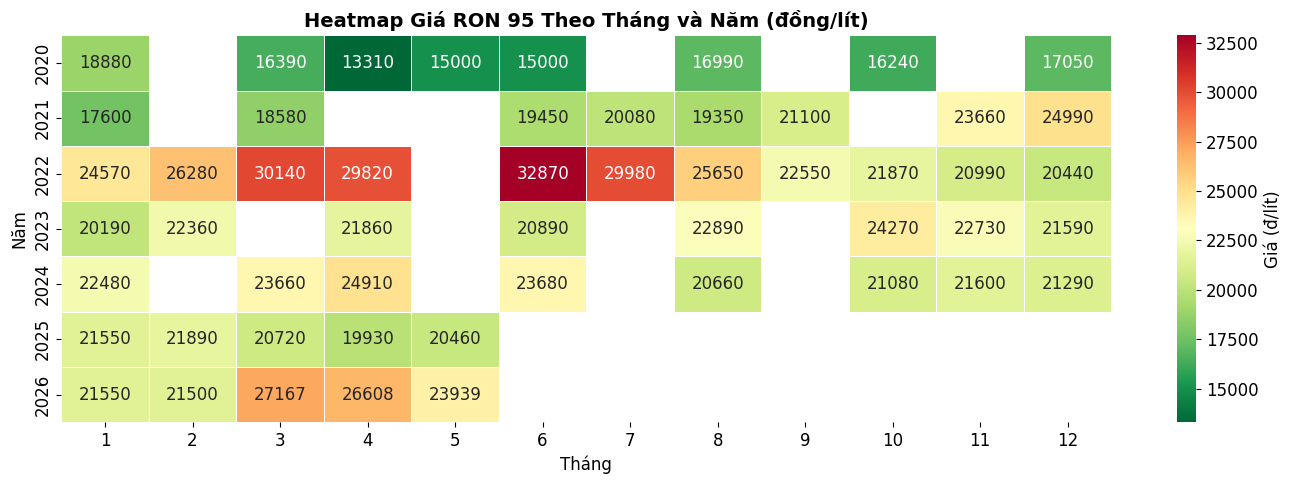

✅ Heatmap cho thấy giá cao nhất vào năm 2022 (màu đỏ đậm)


In [6]:
df['Thang'] = df['Ngay'].dt.month

# Tạo pivot table
pivot = df.pivot_table(values='RON95', index='Nam', columns='Thang', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Giá (đ/lít)'})

ax.set_title('Heatmap Giá RON 95 Theo Tháng và Năm (đồng/lít)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Tháng')
ax.set_ylabel('Năm')
plt.tight_layout()
plt.savefig('heatmap_gia.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Heatmap cho thấy giá cao nhất vào năm 2022 (màu đỏ đậm)')

## 7. Câu hỏi 5: Dự đoán xu hướng (Linear Regression)

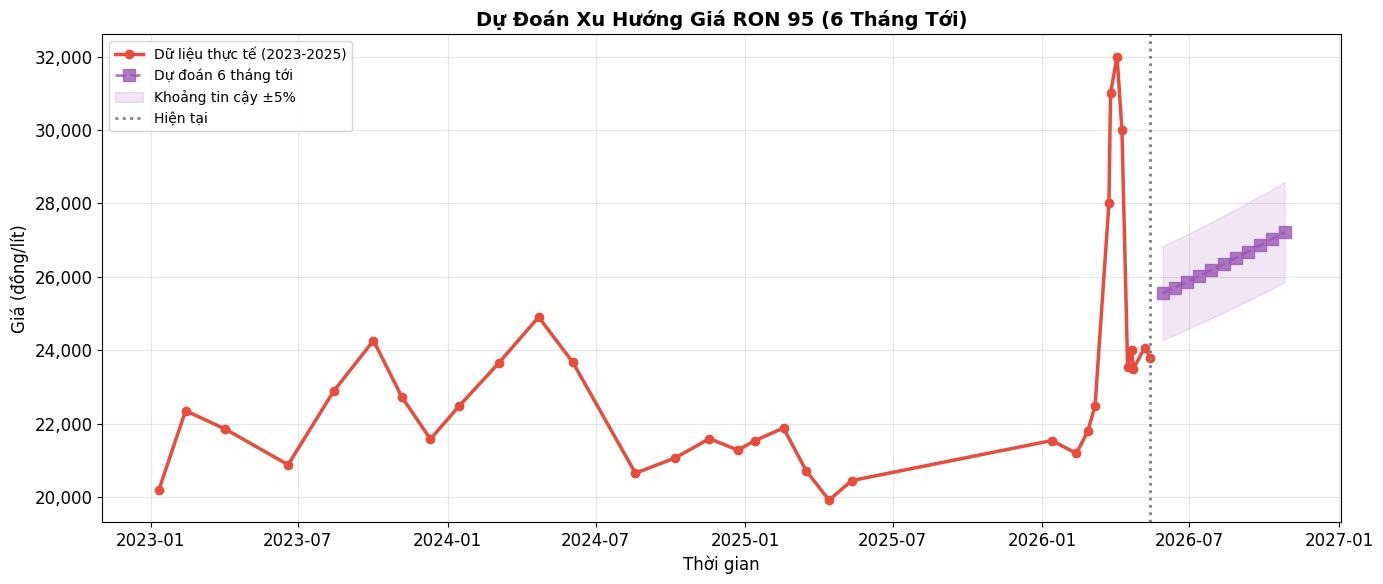


=== DỰ ĐOÁN GIÁ RON 95 (6 THÁNG TỚI) ===
  05/2026: 25,559 đ/lít
  06/2026: 25,867 đ/lít
  07/2026: 26,187 đ/lít
  08/2026: 26,519 đ/lít
  09/2026: 26,862 đ/lít
  10/2026: 27,217 đ/lít


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
import numpy as np

# Lấy dữ liệu từ 2023 trở đi để dự đoán xu hướng gần nhất
df_recent = df[df['Nam'] >= 2023].copy()
df_recent['Timestamp'] = (df_recent['Ngay'] - df_recent['Ngay'].min()).dt.days

X = df_recent[['Timestamp']]
y = df_recent['RON95']

# Polynomial regression bậc 2
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
model = LinearRegression()
model.fit(X_poly, y)

# Dự đoán 6 tháng tới
last_day = df_recent['Timestamp'].max()
future_days = np.arange(last_day + 15, last_day + 180, 15).reshape(-1, 1)
future_pred = model.predict(poly.transform(future_days))

# Tạo ngày tương lai
base_date = df_recent['Ngay'].max()
future_dates = [base_date + pd.Timedelta(days=int(d - last_day)) for d in future_days.flatten()]

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_recent['Ngay'], df_recent['RON95'], 'o-', color='#e74c3c', 
        linewidth=2.5, label='Dữ liệu thực tế (2023-2025)', markersize=6)
ax.plot(future_dates, future_pred, 's--', color='#9b59b6', 
        linewidth=2, label='Dự đoán 6 tháng tới', markersize=8, alpha=0.8)
ax.fill_between(future_dates, future_pred * 0.95, future_pred * 1.05, 
                alpha=0.15, color='#9b59b6', label='Khoảng tin cậy ±5%')
ax.axvline(base_date, color='gray', linestyle=':', linewidth=2, label='Hiện tại')
ax.set_title('Dự Đoán Xu Hướng Giá RON 95 (6 Tháng Tới)', fontsize=14, fontweight='bold')
ax.set_xlabel('Thời gian')
ax.set_ylabel('Giá (đồng/lít)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('du_doan_xu_huong.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== DỰ ĐOÁN GIÁ RON 95 (6 THÁNG TỚI) ===')
for date, pred in zip(future_dates[::2], future_pred[::2]):
    print(f'  {date.strftime("%m/%Y")}: {pred:,.0f} đ/lít')

## 8. Kết luận & Đề xuất

In [8]:
print('=' * 60)
print('  KẾT LUẬN PHÂN TÍCH GIÁ XĂNG DẦU VN (2020–2025)')
print('=' * 60)

print(f"""
1. BIẾN ĐỘNG TỔNG THỂ:
   • Giá RON 95 dao động từ {df['RON95'].min():,} đ đến {df['RON95'].max():,} đ/lít
   • Biên độ dao động: {df['RON95'].max() - df['RON95'].min():,} đ/lít (±{(df['RON95'].max()-df['RON95'].min())/df['RON95'].mean()*100:.0f}%)

2. CÁC GIAI ĐOẠN NỔI BẬT:
   • 2020: Giảm sâu do COVID-19 (thấp nhất: 13,310 đ)
   • 2022: Tăng kỷ lục do xung đột Nga-Ukraine (cao nhất: 32,870 đ)
   • 2023-2025: Ổn định quanh mức 20,000-24,000 đ

3. ĐỀ XUẤT:
   • Nhà nước cần duy trì Quỹ bình ổn giá xăng dầu
   • Người dân nên theo dõi chu kỳ điều chỉnh 10 ngày/lần
   • Xu hướng 2025: Ổn định ở mức 20,000-22,000 đ/lít

4. HẠN CHẾ:
   • Mô hình dự đoán chưa tính đến yếu tố địa chính trị
   • Cần thêm dữ liệu giá dầu Brent thế giới để tăng độ chính xác
""")

  KẾT LUẬN PHÂN TÍCH GIÁ XĂNG DẦU VN (2020–2025)

1. BIẾN ĐỘNG TỔNG THỂ:
   • Giá RON 95 dao động từ 13,310 đ đến 32,870 đ/lít
   • Biên độ dao động: 19,560 đ/lít (±87%)

2. CÁC GIAI ĐOẠN NỔI BẬT:
   • 2020: Giảm sâu do COVID-19 (thấp nhất: 13,310 đ)
   • 2022: Tăng kỷ lục do xung đột Nga-Ukraine (cao nhất: 32,870 đ)
   • 2023-2025: Ổn định quanh mức 20,000-24,000 đ

3. ĐỀ XUẤT:
   • Nhà nước cần duy trì Quỹ bình ổn giá xăng dầu
   • Người dân nên theo dõi chu kỳ điều chỉnh 10 ngày/lần
   • Xu hướng 2025: Ổn định ở mức 20,000-22,000 đ/lít

4. HẠN CHẾ:
   • Mô hình dự đoán chưa tính đến yếu tố địa chính trị
   • Cần thêm dữ liệu giá dầu Brent thế giới để tăng độ chính xác

